# DS14 CSV Model Diagnostics

This notebook loads `DS14.csv`, fits the five candidate models with `scipy.optimize.curve_fit`, and shows a one-step diagnostic plot for the CSV data.

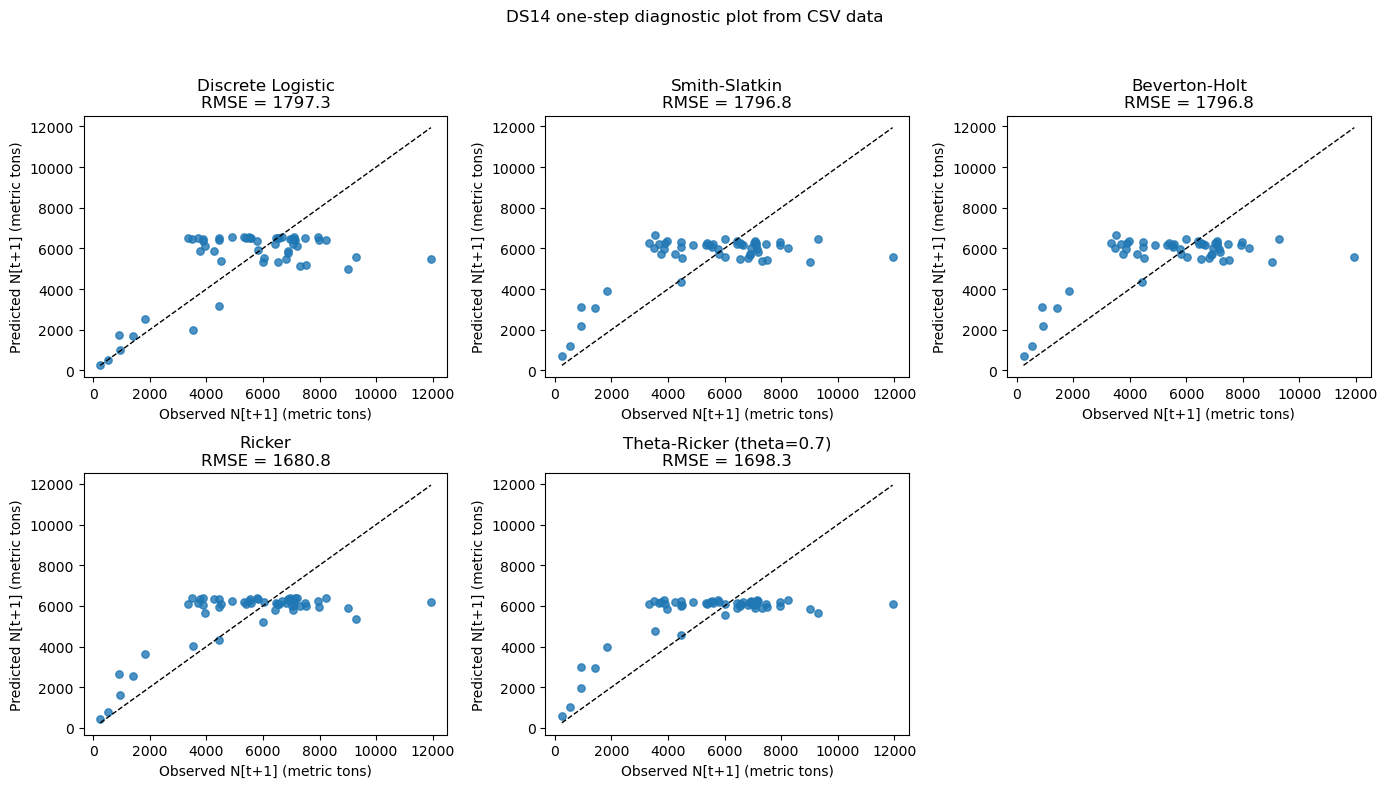

One-step RMSE ranking:
Ricker: 1680.7993
Theta-Ricker (theta=0.7): 1698.2550
Beverton-Holt: 1796.7871
Smith-Slatkin: 1796.7871
Discrete Logistic: 1797.2939


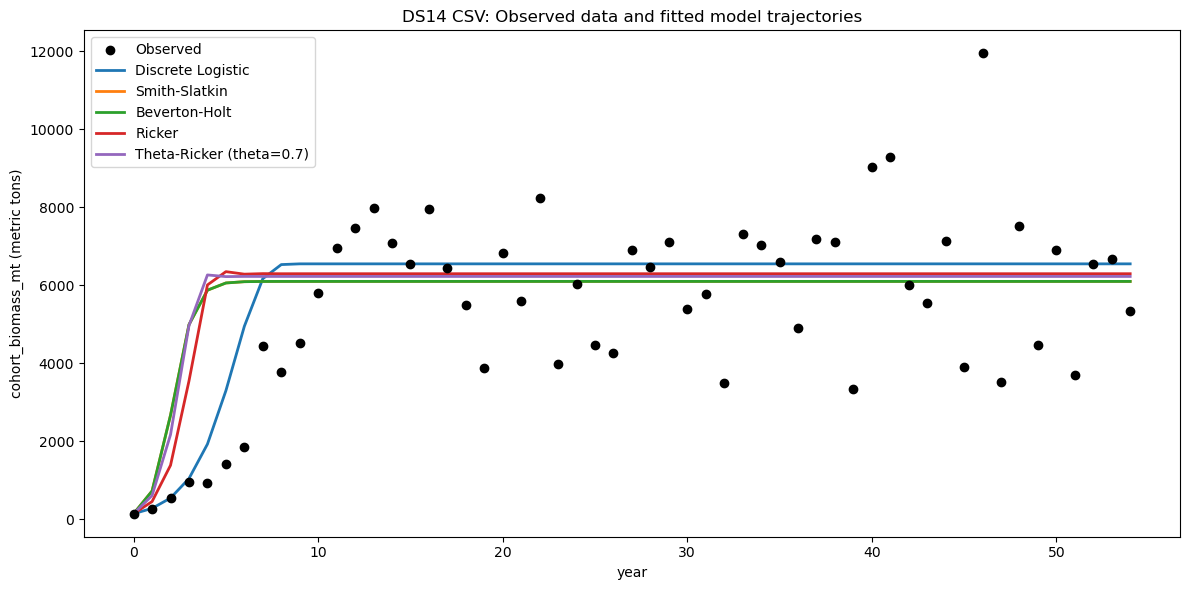

[('Ricker', np.float64(1680.7993280117923)),
 ('Theta-Ricker (theta=0.7)', np.float64(1698.2549848600252)),
 ('Beverton-Holt', np.float64(1796.7870692007161)),
 ('Smith-Slatkin', np.float64(1796.7870694412084)),
 ('Discrete Logistic', np.float64(1797.2939316176405))]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load CSV data
csv_path = 'DS14.csv'
data = pd.read_csv(csv_path)
if 'year' not in data.columns:
    raise ValueError('Expected a year column in DS14.csv')
if 'cohort_biomass_mt' not in data.columns:
    raise ValueError('Expected a cohort_biomass_mt column in DS14.csv')

years = data['year'].to_numpy(dtype=float)
N = data['cohort_biomass_mt'].to_numpy(dtype=float)

# One-step map functions
def logistic_map(Nt, r, K):
    return Nt * (1 + r * (1 - Nt / K))

def smith_slatkin_map(Nt, r, K):
    R = np.exp(r)
    return (Nt * R) / (1 + (R - 1) * Nt / K)

def beverton_holt_map(Nt, lam, alpha):
    return (lam * Nt) / (1 + alpha * Nt)

def ricker_map(Nt, r, K):
    return Nt * np.exp(r * (1 - Nt / K))

THETA = 0.7
def theta_ricker_map(Nt, r, K):
    return Nt * np.exp(r * (1 - (Nt / K) ** THETA))

# Fit models to one-step transitions
x = N[:-1]
y = N[1:]
fits = {}

bounds_rk = ([-5, 1e-6], [5, 1e9])
params, _ = curve_fit(logistic_map, x, y, p0=[0.5, max(N) * 1.2], bounds=bounds_rk, maxfev=20000)
fits['Discrete Logistic'] = (params, logistic_map)

params, _ = curve_fit(smith_slatkin_map, x, y, p0=[0.5, max(N) * 1.2], bounds=bounds_rk, maxfev=20000)
fits['Smith-Slatkin'] = (params, smith_slatkin_map)

params, _ = curve_fit(beverton_holt_map, x, y, p0=[1.1, 1.0 / max(N)], bounds=([1e-6, 0.0], [1e3, 1.0]), maxfev=20000)
fits['Beverton-Holt'] = (params, beverton_holt_map)

params, _ = curve_fit(ricker_map, x, y, p0=[0.5, max(N) * 1.2], bounds=bounds_rk, maxfev=20000)
fits['Ricker'] = (params, ricker_map)

params, _ = curve_fit(theta_ricker_map, x, y, p0=[0.5, max(N) * 1.2], bounds=bounds_rk, maxfev=20000)
fits['Theta-Ricker (theta=0.7)'] = (params, theta_ricker_map)

# Simulate fitted trajectories and compute one-step RMSE
simulations = {}
rmse_rows = []
for name, (params, func) in fits.items():
    traj = [float(N[0])]
    for _ in range(len(N) - 1):
        traj.append(func(traj[-1], *params))
    traj = np.asarray(traj, dtype=float)
    simulations[name] = traj

    y_pred = func(x, *params)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    rmse_rows.append((name, rmse))

rmse_rows = sorted(rmse_rows, key=lambda item: item[1])

# One-step diagnostic plot: observed vs predicted N[t+1]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, (name, (params, func)) in enumerate(fits.items()):
    y_pred = func(x, *params)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    ax = axes[idx]
    ax.scatter(y, y_pred, s=28, alpha=0.8)
    mn = min(y.min(), y_pred.min())
    mx = max(y.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    ax.set_title(f'{name}\nRMSE = {rmse:.1f}')
    ax.set_xlabel('Observed N[t+1] (metric tons)')
    ax.set_ylabel('Predicted N[t+1] (metric tons)')

# Remove the unused last panel
axes[-1].axis('off')

plt.suptitle('DS14 one-step diagnostic plot from CSV data')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print('One-step RMSE ranking:')
for name, rmse in rmse_rows:
    print(f'{name}: {rmse:.4f}')

# Optional combined plot of fitted trajectories on raw biomass scale
plt.figure(figsize=(12, 6))
plt.scatter(years, N, color='black', label='Observed', zorder=5)
for name, traj in simulations.items():
    plt.plot(years, traj, linewidth=2, label=name)
plt.xlabel('year')
plt.ylabel('cohort_biomass_mt (metric tons)')
plt.title('DS14 CSV: Observed data and fitted model trajectories')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

rmse_rows